@author Nikolay Zhabchikov

Предсказания основанные на алгоритме TF-IDF. С помощью этого алгоритма получаются векторные представления слов (эмбеддинг). Затем эмбеддинги слов используются, как признаки в алгоритмах кластеризации (k-means, DBSCAN). Однако, такой подход показывает очень слабые результаты по сравнению с нахождением косинусного сходства эмбеддинга описания и эмбеддинга категории.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
from nltk.stem.snowball import SnowballStemmer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tqdm.pandas()

In [67]:
df = pd.read_csv('data\monitorings_archive\Птица.csv')
cls_df = pd.read_csv('data\categories\Птица_разрубы.csv', sep=';')

df = df.rename(columns={'Категория': 'model_1', 'Новая Категория':'model_2'})

In [68]:
df.head(2)

,Наименование,Описание,Зам./ Охл.,Страна,Упаковка,Наличие,Партия,Условия поставки,Цена,Компания,Вид деятельности,Телефон,Контактное лицо,E-mail,Дата,federal_okrug,Сорт/Категория,Сертификация,model_1,model_2
0,Индейка,Желудки подл.,зам,Россия,"короб 6,4 кг.",Склад,NaN,Возм. доставка,157.0,ООО РУСКОМ,Производитель,"(495) 640-09-10, (964) 647-23-76",Александр,sale2.moscow@sibkolbasy.ru,2015-01-14,NaN,NaN,NaN,гребешки,желудки
1,Перепел,Тушка (20 шт),зам,Россия,шт,Заказ,от кор.,Возм. доставка,60.0,ИМПУЛЬС,Трейдер,"(499) 408-08-05, (925) 280-04-68","Максим, Ирина","0204max@mail.ru, irinakarpunina@mail.ru",2015-01-14,NaN,2 сорт,NaN,тушка,тушка


In [69]:
colum_to_drop = ['Наименование', 'Упаковка', 'Зам./ Охл.', 'Страна', 'Наличие', 'Партия', 'Условия поставки', 'Цена', 'Компания', 'Вид деятельности', 'Телефон', 'Контактное лицо', 'E-mail', 'Дата', 'federal_okrug', 'Сорт/Категория', 'Сертификация', 'model_1', 'model_2']
df = df.drop(colum_to_drop, axis=1)

In [70]:
df.head(2)

,Описание
0,Желудки подл.
1,Тушка (20 шт)


In [ ]:
stemmer = SnowballStemmer("russian") 

def clear_description_stemming(text):
    '''
    Удаление лишних символов и стемминг слов
    '''
    text = re.sub('[^а-яА-Я]+', ' ', text)
    text = re.sub('(без кожи)|(без кожи )|( без кожи)', '', text)
    text = text.lower().strip()
    text = ' '.join([stemmer.stem(word) for word in text.split() if len(word) > 2])
    return text

In [72]:
df['Описание stemming'] = df['Описание'].progress_apply(clear_description_stemming)

100%|██████████| 540013/540013 [00:44<00:00, 12001.47it/s]


In [73]:
df.head(1)

,Описание,Описание stemming
0,Желудки подл.,желудк подл


In [74]:
cls_names = cls_df['value'].unique().tolist()
i_to_cls_name = {i:name for i, name in enumerate(cls_names)}
cls_names_stemming = [clear_description_stemming(cls_) for cls_ in cls_names]

In [75]:
df_train = df.copy()
df_train.drop('Описание', inplace=True, axis=1)

# TF-IDF

tfidf векторизация с сжатием вектора до определенного размера, в следствии чего в словарь попадают не все слова из описания. Сравнение векторов с помощью косинусного сходства

In [ ]:
for feature_number in tqdm([25, 50, 75, 100, 125, 150, 2000]):
    # tfidf векторизация описаний
    tfidf_vectorizer = TfidfVectorizer(max_features=feature_number)
    tfidf_matrix = tfidf_vectorizer.fit_transform(df_train['Описание stemming'])
    df_train_ = pd.concat((df_train, pd.DataFrame(tfidf_matrix.toarray())), axis=1)
    df_train_ = df_train_.drop(['Описание stemming'], axis=1)

    # tfidf векторизация категорий
    cls_emb = tfidf_vectorizer.transform(cls_names_stemming)
    cls_emb_df = pd.DataFrame(cls_emb.toarray())

    # сравнение эмбеддингов
    similarity = cosine_similarity(df_train_.values, cls_emb_df.values)
    preds_categories_index = np.argmax(similarity, axis=1)

    # предсказание категории
    preds_label = [i_to_cls_name.get(item) for item in preds_categories_index]
    df[f'tfidf {feature_number}'] = preds_label

100%|██████████| 7/7 [00:38<00:00,  5.45s/it]


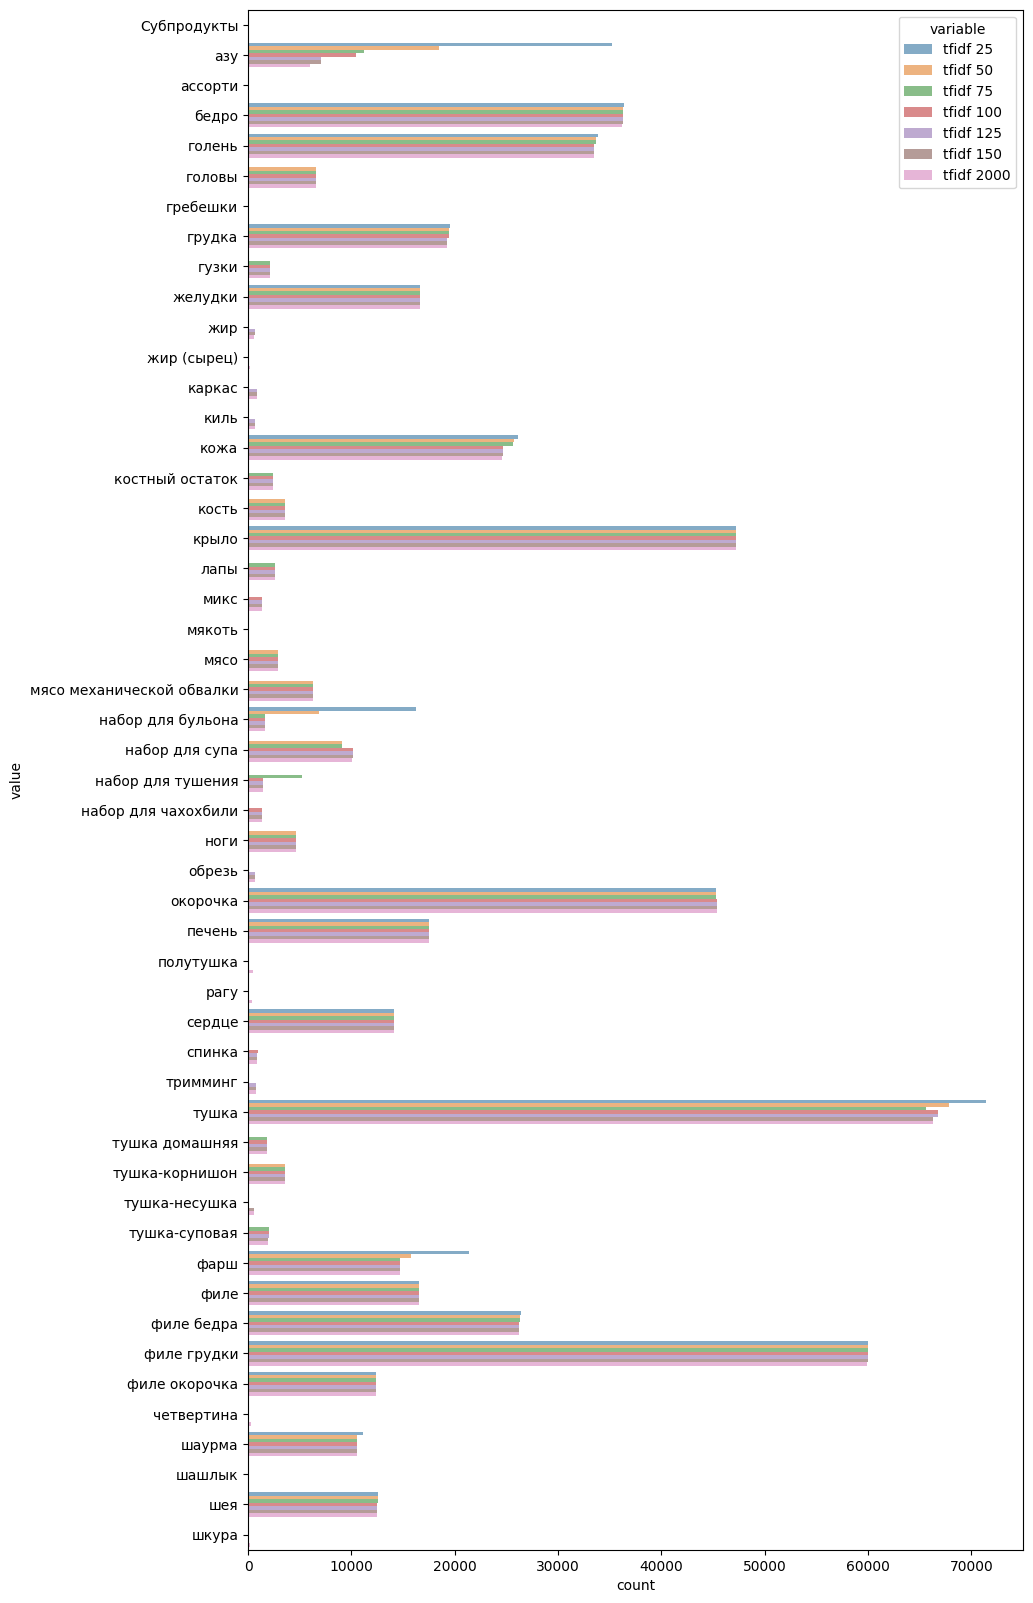

In [77]:
data = df.melt(value_vars=['tfidf 25', 'tfidf 50', 'tfidf 75', 'tfidf 100', 'tfidf 125', 'tfidf 150', 'tfidf 2000'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

Можно заметить, что модели делают практически одинаковые предсказания, кроме моделей с небольшим количеством слов в словаре

# Попробуем другой подход

Будем использовать TruncatedSVD для снижения размерности разреженных векторов после tfidf векторизации

In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df_train['Описание stemming'])

for svd_components in tqdm([25, 50, 75, 100, 125, 150]):
    # tfidf векторизация описаний
    tfidf_matrix_df = pd.DataFrame(np.float32(tfidf_matrix.toarray()))
    # сжатие векторов через сингулярное разложение
    truncated_svd = TruncatedSVD(svd_components, algorithm='arpack', random_state=42)
    svd_df = truncated_svd.fit_transform(tfidf_matrix_df)
    df_train_ = pd.concat((df_train, pd.DataFrame(svd_df)), axis=1)
    df_train_ = df_train_.drop(['Описание stemming'], axis=1)

    # tfidf векторизация категорий
    cls_emb = tfidf.transform(cls_names_stemming)
    # сжатие векторов через сингулярное разложение
    svd_cls_emb = truncated_svd.transform(np.float32(cls_emb.toarray()))
    svd_cls_emb_df = pd.DataFrame(svd_cls_emb)

    # сравнение эмбеддингов
    similarity = cosine_similarity(df_train_.values, svd_cls_emb_df.values)
    preds_categories_index = np.argmax(similarity, axis=1)
    
    # предсказание категории
    preds_label = [i_to_cls_name.get(item) for item in preds_categories_index]
    df[f'truncated svd {svd_components}'] = preds_label

100%|██████████| 6/6 [05:57<00:00, 59.65s/it]


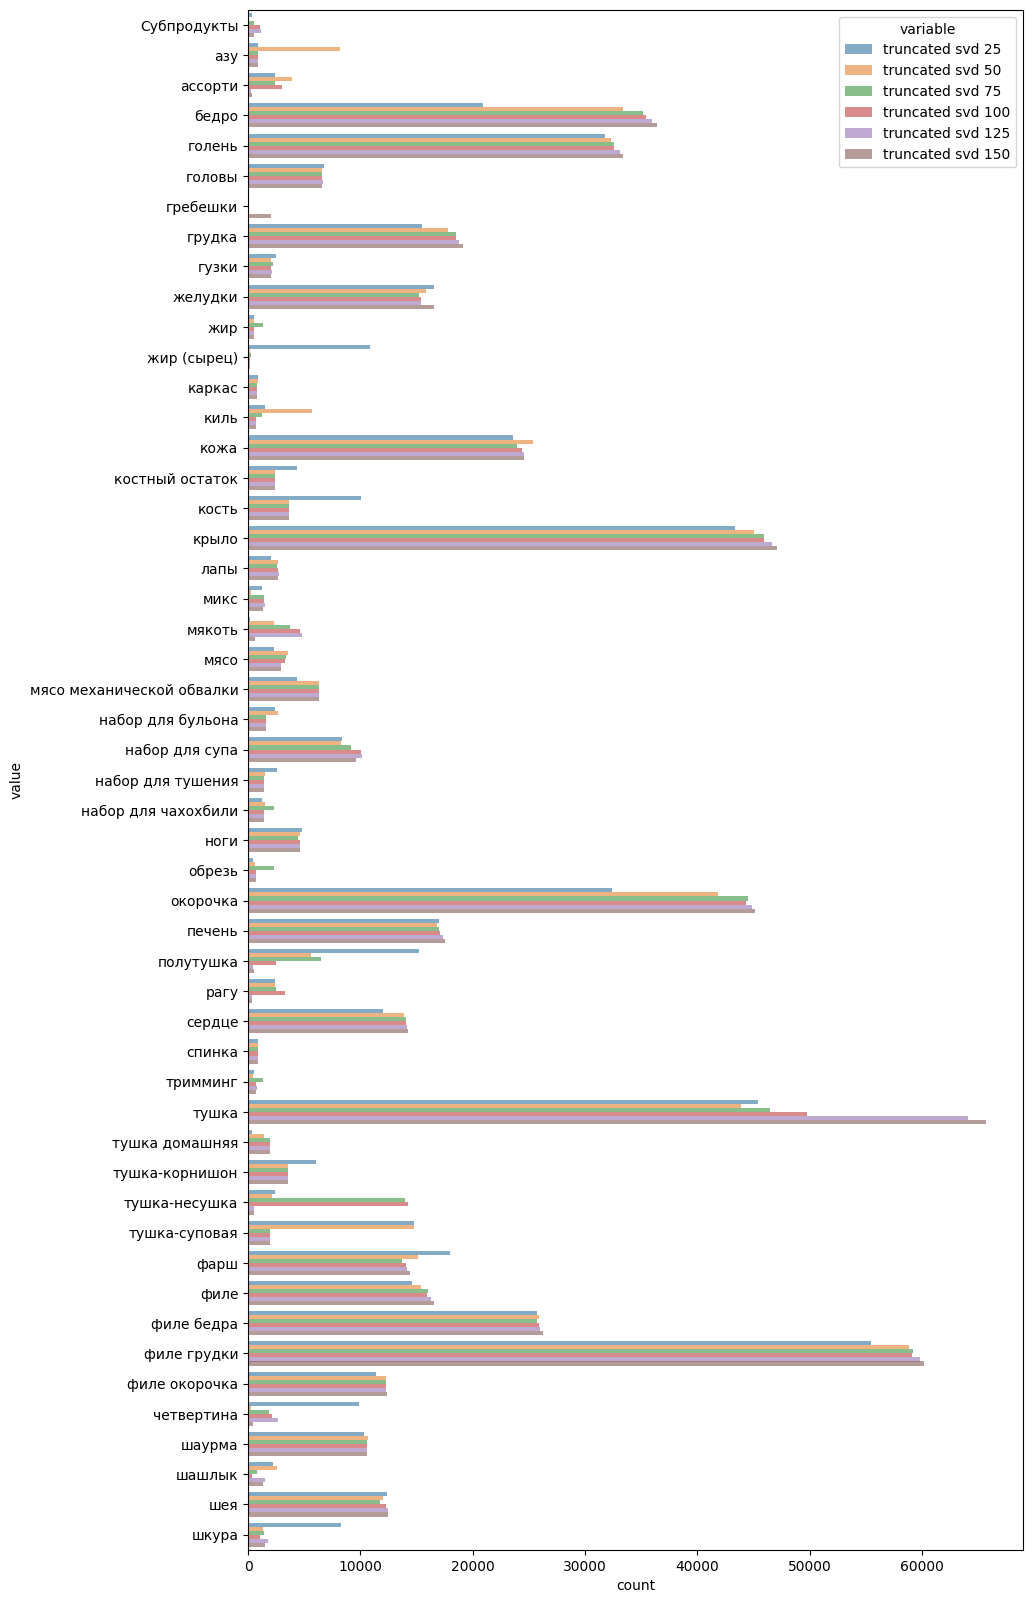

In [79]:
data = df.melt(value_vars=['truncated svd 25', 'truncated svd 50', 'truncated svd 75', 'truncated svd 100', 'truncated svd 125', 'truncated svd 150'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

У такого подхода предсказания более значительно отличаются от размерности вектора. Сравним tfidf 150 и Truncated svd 150

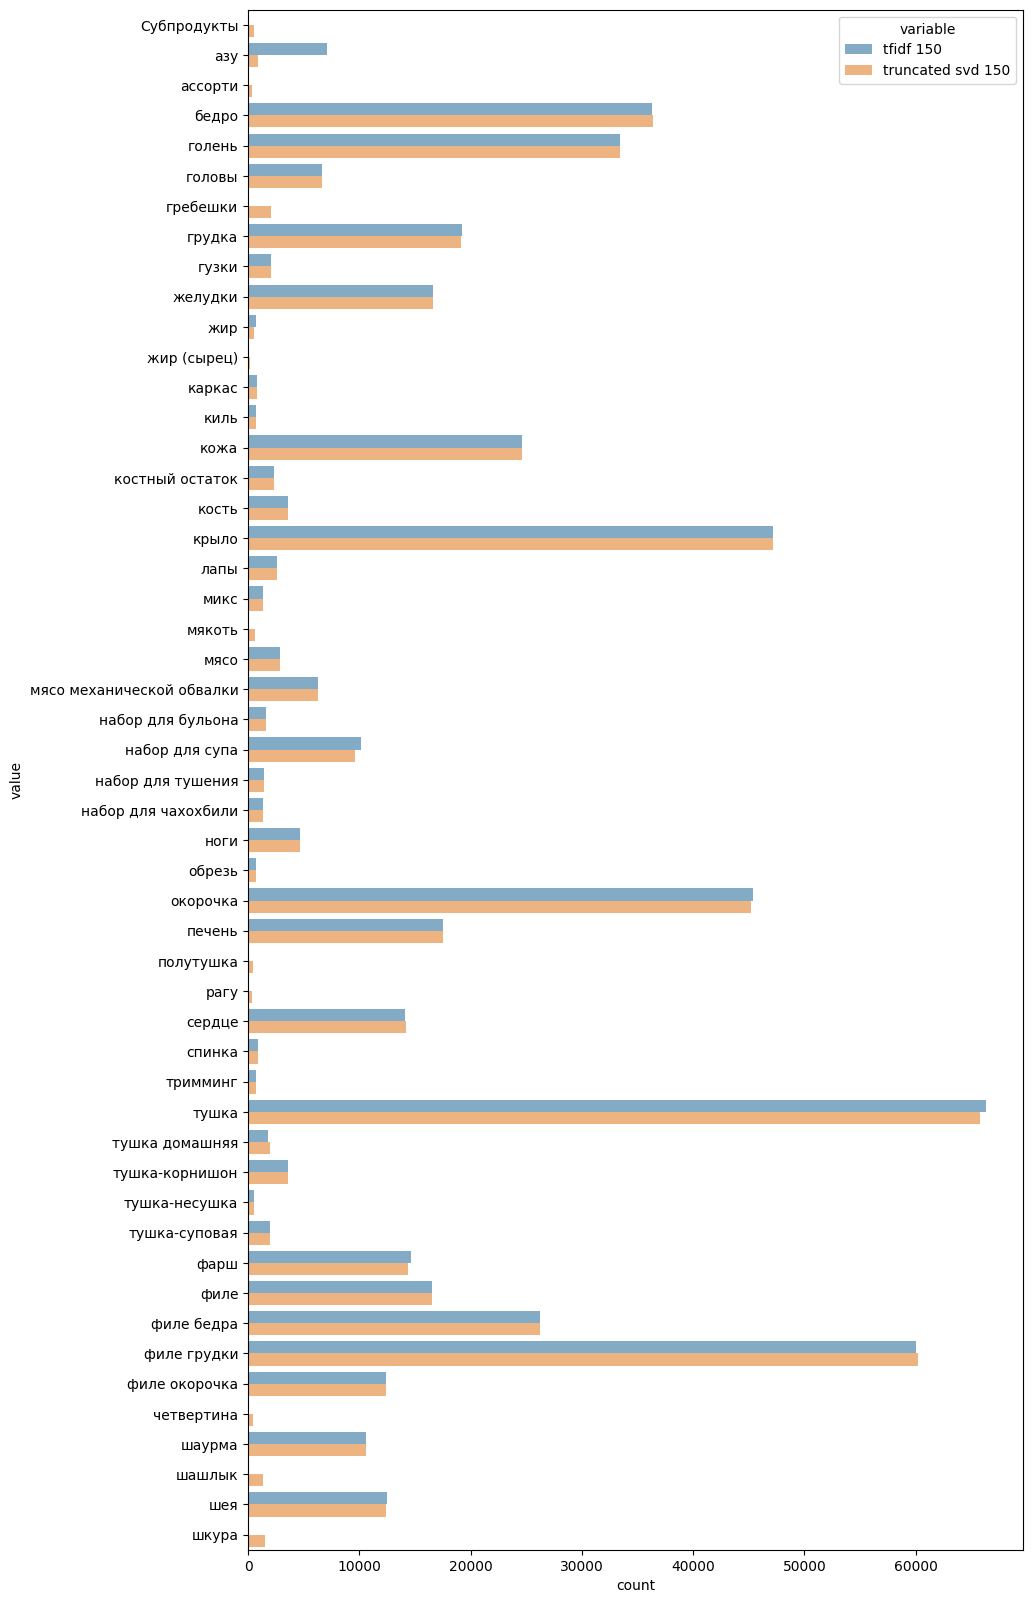

In [80]:
data = df.melt(value_vars=['tfidf 150', 'truncated svd 150'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

In [81]:
df[['tfidf 150', 'truncated svd 150']].describe()

,tfidf 150,truncated svd 150
count,540013,540013
unique,41,51
top,тушка,тушка
freq,66336,65736


Интересно, что tfidf 150 совсем не предсказывает 10 категорий, видимо это достаточно редкие категории и ключевые слова для этих категорий не попали в словарь

In [82]:
tfidf_to_svd = len(df[df['tfidf 150'] == df['truncated svd 150']])

print(f'Всего объектов: {len(df)}')
print(f'совпадений между моделью tfidf и truncated svd: {tfidf_to_svd} / {round(tfidf_to_svd/len(df), 4) * 100}%')

Всего объектов: 540013
совпадений между моделью tfidf и truncated svd: 531410 / 98.41%


In [95]:
df_ = pd.read_csv('data\monitorings_archive\Птица.csv')
df_ = pd.concat((df_, df[['tfidf 150', 'truncated svd 150']]), axis=1)

tfidf_to_model_1 = len(df_[df_['Категория'] == df_['tfidf 150']])
svd_to_model_1 = len(df_[df_['Категория'] == df_['truncated svd 150']])

tfidf_to_model_2 = len(df_[df_['Новая Категория'] == df_['tfidf 150']])
svd_to_model_2 = len(df_[df_['Новая Категория'] == df_['truncated svd 150']])


print(f'Всего объектов: {len(df_)}')
print(f'совпадений между model 1 и tfidf: {tfidf_to_model_1} / {round(tfidf_to_model_1/len(df_), 4) * 100}%')
print(f'совпадений между model 2 и tfidf: {tfidf_to_model_2} / {round(tfidf_to_model_2/len(df_), 4) * 100}%')
print(f'совпадений между model 1 и truncated svd: {svd_to_model_1} / {round(svd_to_model_1/len(df_), 4) * 100}%')
print(f'совпадений между model 2 и truncated svd: {svd_to_model_2} / {round(svd_to_model_2/len(df_), 4) * 100}%')

Всего объектов: 540013
совпадений между model 1 и tfidf: 385559 / 71.39999999999999%
совпадений между model 2 и tfidf: 420739 / 77.91%
совпадений между model 1 и truncated svd: 385274 / 71.35000000000001%
совпадений между model 2 и truncated svd: 419641 / 77.71000000000001%


Текущие модели никак не учитывают порядок слов, также не учитываются отрицательные части "без, не". Могут совсем не предсказывать редкие категории. На каждый датасет нужно обучать свои модели и проводить анализ предсказаний.